In [1]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [2]:
# Cell 2: Load Dataset

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Summary statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
# Missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Remove duplicates
df = df.drop_duplicates()

In [8]:
# Cell 4: Outlier Detection (Corrected IQR Method)

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers only from numeric columns
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

df.shape

(198, 5)

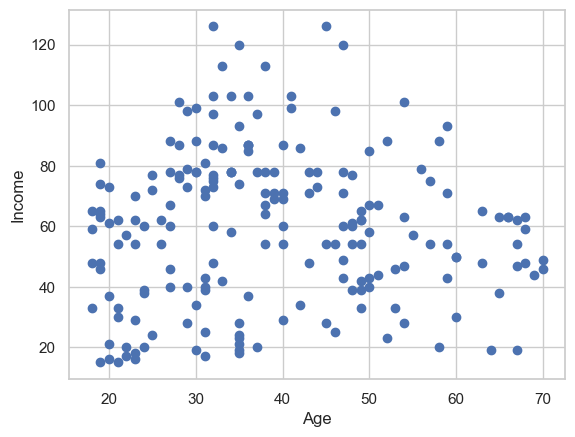

In [9]:
# Age vs Income
plt.scatter(df['Age'], df['Annual Income (k$)'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

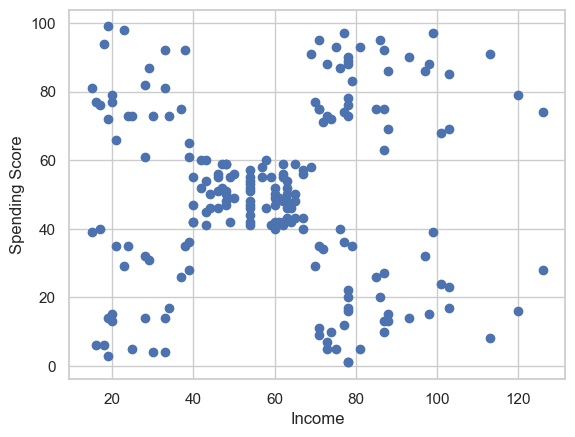

In [10]:
# Income vs Spending
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

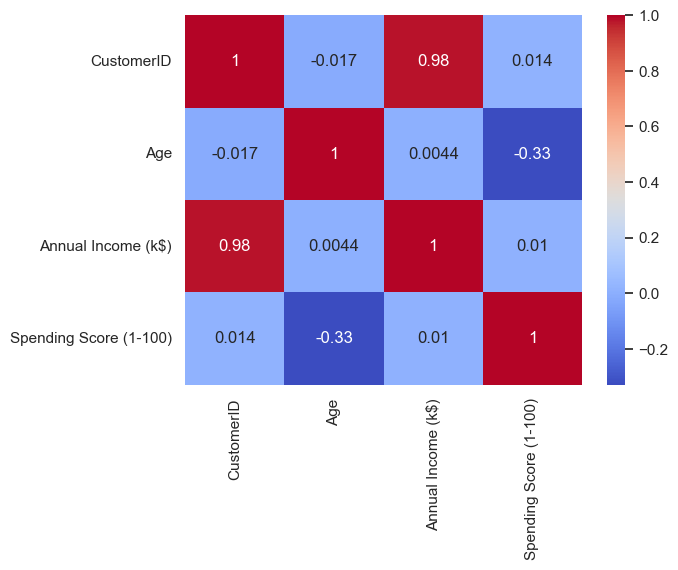

In [11]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset first
df = pd.read_csv("Mall_Customers.csv")

# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Feature selection
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

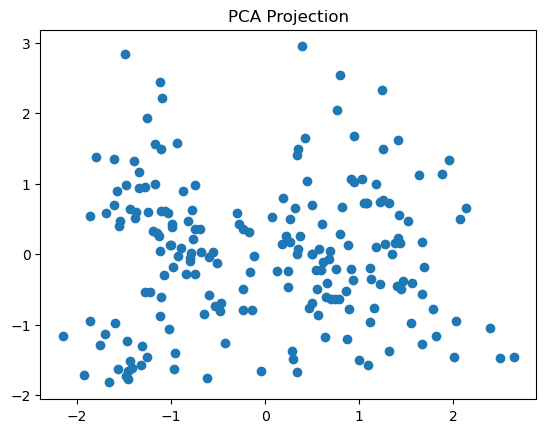

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Projection")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

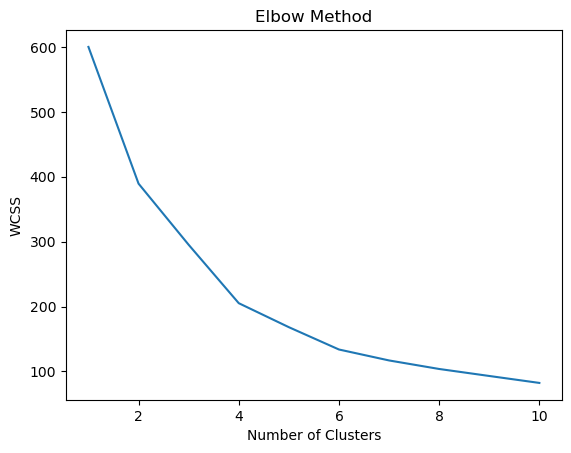

In [10]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Recreate clusters properly (avoid warnings)
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score: 0.41664341513732767


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


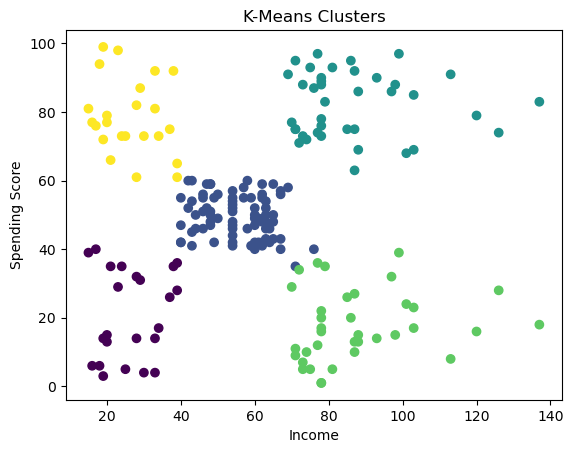

In [14]:
df['Cluster'] = kmeans.fit_predict(X)

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'])

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clusters")
plt.show()

In [16]:
df.groupby('KMeans_Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
KMeans_Cluster,,,,,,
0,24.100000,0.600000,46.250000,26.750000,18.350000,0.000000
1,55.648148,0.592593,25.185185,41.092593,62.240741,2.240741
2,161.025000,0.550000,32.875000,86.100000,81.525000,1.975000
3,159.743590,0.487179,39.871795,86.102564,19.358974,2.794872
4,83.872340,0.574468,55.638298,54.382979,48.851064,1.021277


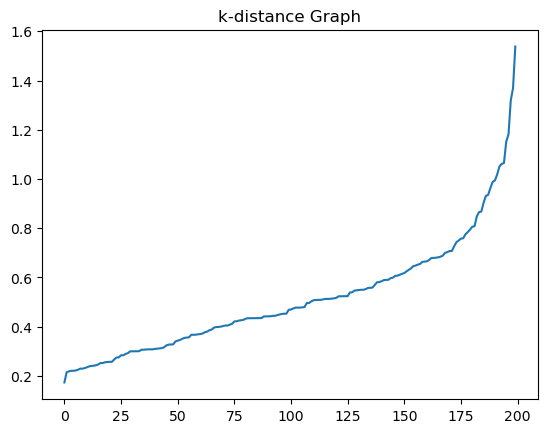

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])
plt.plot(distances)
plt.title("k-distance Graph")
plt.show()

In [19]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_clusters = db.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

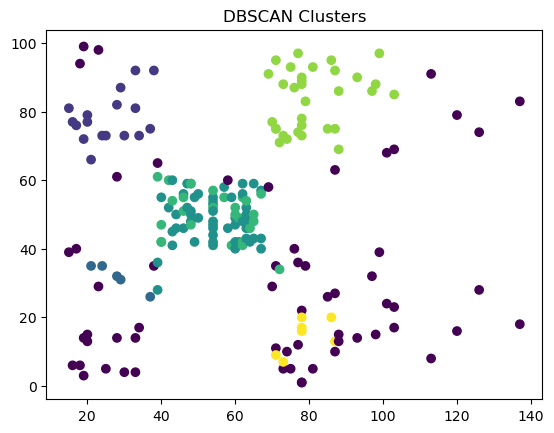

In [20]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=db_clusters)
plt.title("DBSCAN Clusters")
plt.show()

In [21]:
abnormal = df[df['DBSCAN_Cluster'] == -1]
abnormal

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Cluster,DBSCAN_Cluster
0,1,0,19,15,39,1,0,-1
2,3,1,20,16,6,0,0,-1
4,5,1,31,17,40,1,0,-1
6,7,1,35,18,6,0,0,-1
7,8,1,23,18,94,1,4,-1
8,9,0,64,19,3,0,0,-1
10,11,0,67,19,14,0,0,-1
11,12,1,35,19,99,1,4,-1
12,13,1,58,20,15,0,0,-1
14,15,0,37,20,13,0,0,-1


In [22]:
print("Total Customers:", len(df))
print("K-Means Clusters:", df['KMeans_Cluster'].nunique())
print("Abnormal Customers (DBSCAN Noise):", len(abnormal))

Total Customers: 200
K-Means Clusters: 5
Abnormal Customers (DBSCAN Noise): 60
